# XGBoost sobre la DIFERENCIA — Δ log(precio)

En el notebook 04, `log_precio_lag1` se llevó ~0.91 de la ganancia total. No es
un error: la serie es casi una caminata aleatoria, así que el precio de ayer es
el mejor predictor individual del de mañana. Coincide con el `d=1` que salió del
ACF/PACF en el EDA y con el coeficiente de 0.848 del precio rezagado en
Fedesarrollo.

El problema es para la **fase de interpretabilidad**: si SHAP solo dice "el
precio de ayer explica el precio de hoy", los determinantes hidrológicos y de
FNCER —el vacío que declara la propuesta— quedan invisibles.

**Qué cambia aquí**

| | Notebook 04 | Este notebook |
|---|---|---|
| Objetivo | `log_precio(t)` | `Δ log_precio(t)` |
| Bloque AR | lag1, ma30, sd7 del nivel | lags de la **diferencia** + desviación de la media |
| Qué explican las exógenas | el nivel | el **cambio** |
| Acierto direccional | `signo(ŷ_t − y_{t−1})` vs `signo(y_t − y_{t−1})` | la misma definición |

La reconstrucción a nivel es
`log_precio(t) = log_precio(t−1) + Δ̂ log_precio(t)`,
usando el valor **observado** en t−1 — legítimo para pronóstico a 1 día.

Todas las métricas se calculan sobre el nivel reconstruido en COP/kWh, así que
son directamente comparables con las del notebook 04.

Las exógenas salen del modelo ganador de la etapa 3 (`salidas_seleccion/modelo_final.json`, elegido sobre validación 2020-2022). Toda tabla incluye el **pronóstico ingenuo** (precio de ayer, Δ̂ = 0) y su prueba DM.

In [1]:
import warnings, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("xgboost", xgb.__version__)

xgboost 3.4.1


## 1. Configuración

In [2]:
BASE = Path(r"C:\Users\andre\OneDrive\cosas de la universidad\Uniandes\VIII\Tesis")

CONFIG = {
    "panel_path":        BASE / "data" / "panel_d.parquet",
    "modelo_final_json": BASE / "salidas_seleccion" / "modelo_final.json",
    "out_dir":           BASE / "salidas_modelos",
    "target_col": "precio_ponderado",

    "dev_end":    "2022-12-31",
    "test_start": "2023-01-01",
    "test_end":   "2025-12-31",

    "gap_days":    30,
    "n_splits_cv": 5,
    "refit_every": 30,
    "min_train":   730,
    "horizon":     1,
    "seed":        42,

    # Salida del notebook 04, para comparar formulaciones
    "pred_nivel_csv": BASE / "salidas_modelos" / "predicciones_xgboost.csv",
}

NOMBRE_INGENUO = "Ingenuo (precio ayer)"

# --- Bloque AR reformulado -------------------------------------------------
# Al modelar la diferencia, meter log_precio_lag1 reintroduciria el nivel y el
# problema volveria. Se usan lags de la DIFERENCIA (momentum) y una desviacion
# respecto a la media movil (reversion a la media), ambas estacionarias.
AR_DIFF = [
    "dlog_lag1",        # cambio de ayer — ¿el movimiento persiste o rebota?
    "dlog_lag2",
    "dlog_lag7",
    "dlog_sd7",         # volatilidad reciente de los cambios
    "desv_ma30",        # log_precio(t-1) - media movil 30d: reversion a la media
]

# RESPALDO: solo se usa si falta modelo_final.json
EXOG_RESPALDO = {
    "HIDRO": [
        "aportes_pct_sistema_lag1", "aportes_por_rio_lag2",
        "aportes_media_hist_lag30", "volumen_util_pct_lag1",
        "inv_volumen_util_pct_lag1", "volumen_util_pct_emb_d7", "oni_lag1",
    ],
    "OFERTA": [
        "disp_declarada_lag0",   # reemplaza a disp_comercial_lag0 (se ajusta ex post)
        "margen_reserva_lag0", "margen_reserva_lag7",
        "disp_declarada_d7", "gen_programada_lag7",
    ],
}

def cargar_modelo_final(cfg, respaldo):
    """
    Lee las features del modelo elegido en la etapa 3 (validacion 2020-2022).
    Si falta el archivo usa 'respaldo' y avisa: lo correcto es correr 03.
    """
    ruta = Path(cfg["modelo_final_json"])
    if not ruta.exists():
        print(f"[!] No encuentro {ruta}.\n    Uso las features de RESPALDO. "
              f"Corre 03_bloques_candidatos.py para que salgan del pipeline.")
        return respaldo, None
    info = json.loads(ruta.read_text(encoding="utf-8"))
    val_fin = pd.Timestamp(info["ventana_validacion"][1])
    if val_fin >= pd.Timestamp(cfg["test_start"]):
        raise ValueError(
            f"La etapa 3 eligio el modelo con datos hasta {val_fin.date()}, "
            f"dentro del periodo de prueba. Corrige 01/03 antes de seguir.")
    if info.get("test_start") != cfg["test_start"]:
        print(f"[!] test_start del pipeline ({info.get('test_start')}) "
              f"distinto al de este notebook ({cfg['test_start']})")
    print(f"Modelo de la etapa 3: {info['modelo']}")
    print(f"  criterio:   {info['criterio']}")
    print(f"  validacion: {info['ventana_validacion'][0]} -> "
          f"{info['ventana_validacion'][1]}")
    return info["bloques"], info


bloques, INFO_MODELO = cargar_modelo_final(CONFIG, EXOG_RESPALDO)
# El bloque AR en nivel se reemplaza por AR_DIFF; las exógenas son las del modelo final
EXOG = {b: cols for b, cols in bloques.items() if b != "AR"}
FEATURES = {"AR_DIFF": AR_DIFF, **EXOG}
EXOG_COLS = list(dict.fromkeys(f for lst in EXOG.values() for f in lst))
TODAS = AR_DIFF + [f for f in EXOG_COLS if f not in AR_DIFF]
print(f"{len(TODAS)} features: {len(AR_DIFF)} AR-diff + "
      + ", ".join(f"{len(c)} {b.lower()}" for b, c in EXOG.items()))

Modelo de la etapa 3: AR+HIDRO+OFERTA
  criterio:   menor MAPE en validacion entre los modelos que mejoran la base AR con DM<0 y p_FDR<0.05
  validacion: 2020-01-01 -> 2022-12-31
17 features: 5 AR-diff + 7 hidro, 5 oferta


## 2. Carga y construcción

Todas las estadísticas móviles usan `shift(1)` antes del rolling.

In [3]:
def cargar_panel(cfg):
    p = Path(cfg["panel_path"])
    df = pd.read_parquet(p) if p.suffix == ".parquet" else pd.read_csv(p)
    if "fecha" in df.columns:
        df["fecha"] = pd.to_datetime(df["fecha"]); df = df.set_index("fecha")
    else:
        df.index = pd.to_datetime(df.index)
    return df.sort_index().asfreq("D")


def construir(df, cfg):
    if "volumen_util_pct" in df.columns and "inv_volumen_util_pct" not in df.columns:
        v = pd.to_numeric(df["volumen_util_pct"], errors="coerce")
        piso = 0.02 if v.max() <= 1.5 else 2.0
        df["inv_volumen_util_pct"] = 1.0 / v.clip(lower=piso)

    nivel = pd.to_numeric(df[cfg["target_col"]], errors="coerce")
    logp = np.log(nivel.clip(lower=1e-6))

    # EL OBJETIVO: la diferencia
    dlog = logp.diff().rename("y")

    F = {}
    F["dlog_lag1"] = dlog.shift(1)
    F["dlog_lag2"] = dlog.shift(2)
    F["dlog_lag7"] = dlog.shift(7)
    F["dlog_sd7"]  = dlog.shift(1).rolling(7, min_periods=4).std()
    F["desv_ma30"] = logp.shift(1) - logp.shift(1).rolling(30, min_periods=15).mean()

    for feat in EXOG_COLS:
        if feat.endswith("_d7"):
            base = feat[:-3]
            if base in df.columns:
                s = pd.to_numeric(df[base], errors="coerce")
                F[feat] = s.shift(1) - s.shift(8)
        elif "_lag" in feat:
            base, lag = feat.rsplit("_lag", 1)
            if base in df.columns:
                s = pd.to_numeric(df[base], errors="coerce")
                F[feat] = s if int(lag) == 0 else s.shift(int(lag))

    X = pd.DataFrame(F, index=df.index)
    faltan = [f for f in TODAS if f not in X.columns]
    if faltan:
        print(f"  [!] FALTAN: {faltan}")
    return X[[f for f in TODAS if f in X.columns]], dlog, logp, nivel


df = cargar_panel(CONFIG)
X, y_d, logp, nivel = construir(df, CONFIG)
print(f"panel  {df.shape}")
print(f"X      {X.shape}   cobertura media {X.notna().mean().mean():.1%}")
print(f"objetivo Δlog: media {y_d.mean():+.5f}  sd {y_d.std():.4f}  "
      f"rango [{y_d.min():+.3f}, {y_d.max():+.3f}]")

panel  (4018, 59)
X      (4018, 17)   cobertura media 99.9%
objetivo Δlog: media +0.00011  sd 0.1422  rango [-0.998, +1.007]


### El objetivo ahora sí es estacionario

Es la razón de fondo por la que esta formulación ayuda: el nivel tiene una raíz
unitaria (ACF que decae lento), la diferencia no.

log_precio (nivel)     ADF p = 0.00632  ESTACIONARIA
Δ log_precio           ADF p = 0.00000  ESTACIONARIA


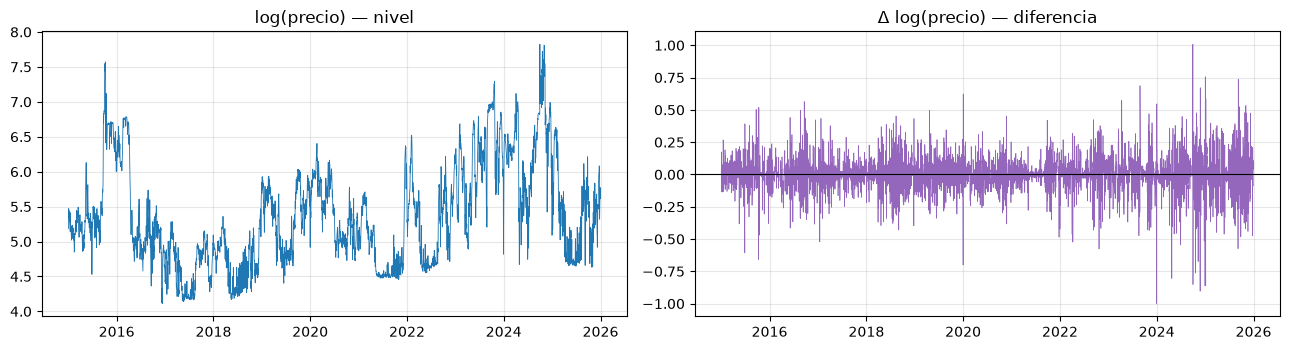

In [4]:
from statsmodels.tsa.stattools import adfuller

for nombre, s in [("log_precio (nivel)", logp), ("Δ log_precio", y_d)]:
    p = adfuller(s.dropna(), autolag="AIC")[1]
    print(f"{nombre:22s} ADF p = {p:.5f}  "
          f"{'ESTACIONARIA' if p < 0.05 else 'NO estacionaria'}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(logp, lw=.6); axes[0].set_title("log(precio) — nivel")
axes[1].plot(y_d, lw=.5, color="tab:purple"); axes[1].axhline(0, c="k", lw=.8)
axes[1].set_title("Δ log(precio) — diferencia")
plt.tight_layout(); plt.show()

## 3. Nivel 1 — split principal

In [5]:
dev_end  = pd.Timestamp(CONFIG["dev_end"])
test_ini = pd.Timestamp(CONFIG["test_start"])
test_fin = pd.Timestamp(CONFIG["test_end"])

X_dev, y_dev = X.loc[:dev_end], y_d.loc[:dev_end]
print(f"DESARROLLO  {X_dev.index.min().date()} -> {X_dev.index.max().date()}  ({len(X_dev)} d)")
print(f"PRUEBA      {test_ini.date()} -> {test_fin.date()}  "
      f"({len(X.loc[test_ini:test_fin])} d)")

DESARROLLO  2015-01-01 -> 2022-12-31  (2922 d)
PRUEBA      2023-01-01 -> 2025-12-31  (1096 d)


## 4. Nivel 2 — hiperparámetros

Ojo: el MAPE no sirve como criterio aquí, porque el objetivo es una diferencia
que cruza cero (dividir por algo cercano a cero explota). Se optimiza el **RMSE
de la diferencia**, y el MAPE en niveles se reporta después.

In [6]:
ESPACIO = {
    "n_estimators":     [200, 400, 600, 800],
    "max_depth":        [2, 3, 4, 5, 6],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10, 20],
    "reg_lambda":       [0.5, 1.0, 3.0, 10.0],
}

def muestrear(rng):
    return {k: rng.choice(v).item() for k, v in ESPACIO.items()}


def cv_score(params, X_dev, y_dev, cfg, n_splits=5):
    d = pd.concat([X_dev, y_dev], axis=1).dropna()
    if len(d) < 500:
        return np.inf
    Xd, yd = d[X_dev.columns].values, d["y"].values
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=cfg["gap_days"])
    sc = []
    for tr, va in tscv.split(Xd):
        m = xgb.XGBRegressor(**params, random_state=cfg["seed"],
                             n_jobs=-1, tree_method="hist")
        m.fit(Xd[tr], yd[tr])
        sc.append(np.sqrt(np.mean((yd[va] - m.predict(Xd[va])) ** 2)))
    return float(np.mean(sc))


N_ITER = 30
rng = np.random.default_rng(CONFIG["seed"])
t0, res = time.time(), []
for i in range(N_ITER):
    p = muestrear(rng)
    res.append({"iter": i, "rmse_cv": cv_score(p, X_dev, y_dev, CONFIG,
                                               CONFIG["n_splits_cv"]), **p})
    if (i + 1) % 5 == 0:
        print(f"  [{i+1:>2}/{N_ITER}] mejor RMSE(Δ): "
              f"{min(r['rmse_cv'] for r in res):.5f}  ({time.time()-t0:.0f}s)")

busq = pd.DataFrame(res).sort_values("rmse_cv")
MEJORES = {k: busq.iloc[0][k] for k in ESPACIO}
for k in ("n_estimators", "max_depth", "min_child_weight"):
    MEJORES[k] = int(MEJORES[k])
print(f"\nMejor RMSE(Δ) en CV: {busq.iloc[0]['rmse_cv']:.5f}")
for k, v in MEJORES.items():
    print(f"  {k:18s} {v}")

  [ 5/30] mejor RMSE(Δ): 0.11265  (33s)


  [10/30] mejor RMSE(Δ): 0.11265  (73s)


  [15/30] mejor RMSE(Δ): 0.11265  (115s)


  [20/30] mejor RMSE(Δ): 0.11265  (149s)


  [25/30] mejor RMSE(Δ): 0.11265  (180s)


  [30/30] mejor RMSE(Δ): 0.11265  (205s)

Mejor RMSE(Δ) en CV: 0.11265
  n_estimators       600
  max_depth          3
  learning_rate      0.01
  subsample          0.9
  colsample_bytree   1.0
  min_child_weight   10
  reg_lambda         10.0


## 5. Nivel 3 — walk-forward y reconstrucción del nivel

El modelo predice la diferencia; el nivel se reconstruye sumando el
`log_precio(t−1)` **observado**. En pronóstico a 1 día eso es información
pasada, no fuga.

In [7]:
def walk_forward_diff(X, y_d, logp, params, cfg, ventana="expansiva",
                      años=3, etiqueta=""):
    idx = X.loc[cfg["test_start"]:cfg["test_end"]].index
    pred_d = pd.Series(index=idx, dtype=float)
    fechas = list(idx)
    bloques = list(range(0, len(fechas), cfg["refit_every"]))
    t0 = time.time()

    for j, i in enumerate(bloques):
        chunk = fechas[i:i + cfg["refit_every"]]
        corte = chunk[0] - pd.Timedelta(days=cfg["horizon"])
        ini = (corte - pd.DateOffset(years=años)
               if ventana == "deslizante" else X.index.min())

        tr = pd.concat([X.loc[ini:corte], y_d.loc[ini:corte]], axis=1).dropna()
        if len(tr) < cfg["min_train"]:
            continue
        m = xgb.XGBRegressor(**params, random_state=cfg["seed"],
                             n_jobs=-1, tree_method="hist")
        m.fit(tr[X.columns].values, tr["y"].values)

        te = X.loc[chunk].dropna()
        if not te.empty:
            pred_d.loc[te.index] = m.predict(te.values)

        pct = (j + 1) / len(bloques)
        eta = (time.time() - t0) / pct - (time.time() - t0)
        print(f"\r  {etiqueta:22s} [{j+1:>2}/{len(bloques)}] {pct:4.0%} "
              f"ETA {eta:3.0f}s", end="", flush=True)
    print(f"\r  {etiqueta:22s} [{len(bloques)}/{len(bloques)}] 100%  "
          f"({time.time()-t0:.0f}s)            ")

    # reconstruccion: log(t) = log(t-1) observado + delta predicho
    pred_log = logp.shift(1).reindex(pred_d.index) + pred_d
    return pred_d, pred_log


print("Entrenando...")
pd_exp, pl_exp = walk_forward_diff(X, y_d, logp, MEJORES, CONFIG,
                                   "expansiva", etiqueta="Δ expansiva")
pd_des, pl_des = walk_forward_diff(X, y_d, logp, MEJORES, CONFIG,
                                   "deslizante", etiqueta="Δ deslizante 3a")

Entrenando...


  Δ expansiva            [ 1/37]   3% ETA  39s

  Δ expansiva            [ 2/37]   5% ETA  43s

  Δ expansiva            [ 3/37]   8% ETA  43s

  Δ expansiva            [ 4/37]  11% ETA  42s

...

  Δ deslizante 3a        [34/37]  92% ETA   4s

  Δ deslizante 3a        [35/37]  95% ETA   3s

  Δ deslizante 3a        [36/37]  97% ETA   1s

  Δ deslizante 3a        [37/37] 100% ETA  -0s

  Δ deslizante 3a        [37/37] 100%  (55s)            


## 6. Métricas — en niveles, comparables con el notebook 04

In [8]:
def metricas(pred_log, logp, nivel=None, y_d=None, pred_d=None):
    """
    Métricas sobre el nivel reconstruido (comparables con el notebook 04).

    Acierto direccional con la MISMA definición del notebook 04 y las etapas 02/03:
        signo(log_t − log_{t−1}) == signo(pred_log_t − log_{t−1}),  log_{t−1} OBSERVADO.
    En el modelo de diferencia es exactamente signo(Δ real) == signo(Δ predicho).
    El pronóstico ingenuo no predice dirección: DA = NaN.
    Pasar SIEMPRE la serie logp completa: el valor de ayer se toma de ahí.
    (nivel, y_d y pred_d quedan en la firma por compatibilidad; no se usan.)
    """
    prev = logp.shift(CONFIG["horizon"])
    d = pd.concat([logp.rename("real_log"), pred_log.rename("pred_log"),
                   prev.rename("prev")], axis=1).dropna()
    if d.empty:
        return {}
    a, p = np.exp(d["real_log"]), np.exp(d["pred_log"])
    mov = d["pred_log"] - d["prev"]
    da = (float((np.sign(d["real_log"] - d["prev"]) == np.sign(mov)).mean() * 100)
          if (mov.abs() > 1e-12).any() else np.nan)
    return {
        "n": len(d),
        "MAPE_%":   float((np.abs((a - p) / a)).mean() * 100),
        "RMSE_COP": float(np.sqrt(((a - p) ** 2).mean())),
        "MAE_COP":  float((a - p).abs().mean()),
        "RMSE_log": float(np.sqrt(((d["real_log"] - d["pred_log"]) ** 2).mean())),
        "DA_%":     da,
    }


# Pronóstico ingenuo: log(t) = log(t−1), es decir Δ̂ = 0
pl_ing = logp.shift(CONFIG["horizon"]).reindex(pl_exp.index)
pd_ing = pd.Series(0.0, index=pl_exp.index)

modelos = {NOMBRE_INGENUO: (pd_ing, pl_ing),
           "Δ expansiva": (pd_exp, pl_exp), "Δ deslizante": (pd_des, pl_des)}
MODELOS_DIF = [k for k in modelos if k != NOMBRE_INGENUO]

tabla = pd.DataFrame({k: metricas(pl, logp) for k, (pdd, pl) in modelos.items()}).T
print("MODELO DE DIFERENCIA — global (2023-2025)")
print(tabla.round(3).to_string())

MODELO DE DIFERENCIA — global (2023-2025)
                            n  MAPE_%  RMSE_COP  MAE_COP  RMSE_log    DA_%
Ingenuo (precio ayer)  1096.0  12.855   118.061   55.627     0.187     NaN
Δ expansiva            1096.0  12.499   113.954   53.176     0.175  63.595
Δ deslizante           1096.0  12.667   114.287   53.575     0.177  63.047


## 7. Comparación directa contra la formulación en nivel

Carga las predicciones del notebook 04. Si no existen, corre ese notebook primero.

In [9]:
ruta_nivel = Path(CONFIG["pred_nivel_csv"])
tiene_nivel = ruta_nivel.exists()

if tiene_nivel:
    prev_nb04 = pd.read_csv(ruta_nivel, index_col=0, parse_dates=True)
    pl_nivel = prev_nb04["xgb_expansiva"]       # ya está en log
    comp = {NOMBRE_INGENUO: metricas(pl_ing, logp),
            "NIVEL (nb 04)": metricas(pl_nivel, logp)}
    for k in MODELOS_DIF:
        comp[f"DIFERENCIA — {k}"] = metricas(modelos[k][1], logp)
    comp = pd.DataFrame(comp).T
    print("COMPARACIÓN DE FORMULACIONES (mismo periodo, mismas unidades, misma definición de DA)")
    print(comp.round(3).to_string())

    mejor_dif = tabla.loc[MODELOS_DIF, "MAPE_%"].idxmin()
    delta = comp.loc["NIVEL (nb 04)", "MAPE_%"] - tabla.loc[mejor_dif, "MAPE_%"]
    print(f"\nMAPE: la diferencia mejora {delta:+.3f} pp sobre el nivel")
    dda = tabla.loc[mejor_dif, "DA_%"] - comp.loc["NIVEL (nb 04)", "DA_%"]
    print(f"Acierto direccional: {dda:+.1f} pp")
else:
    print(f"No encuentro {ruta_nivel}. Corre 04_xgboost.ipynb primero para "
          f"comparar ambas formulaciones.")
    comp = None

COMPARACIÓN DE FORMULACIONES (mismo periodo, mismas unidades, misma definición de DA)
                                n  MAPE_%  RMSE_COP  MAE_COP  RMSE_log    DA_%
Ingenuo (precio ayer)      1096.0  12.855   118.061   55.627     0.187     NaN
NIVEL (nb 04)              1096.0  12.576   113.315   57.661     0.171  61.861
DIFERENCIA — Δ expansiva   1096.0  12.499   113.954   53.176     0.175  63.595
DIFERENCIA — Δ deslizante  1096.0  12.667   114.287   53.575     0.177  63.047

MAPE: la diferencia mejora +0.077 pp sobre el nivel
Acierto direccional: +1.7 pp


### Diebold-Mariano

Se comparan los errores del **nivel reconstruido** (en log), que es la única
escala en la que todos los modelos son comparables. Primero cada modelo contra
el pronóstico ingenuo; después las formulaciones entre sí.

In [10]:
def diebold_mariano(e1, e2, h=1, power=2):
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    ok = np.isfinite(e1) & np.isfinite(e2)
    e1, e2 = e1[ok], e2[ok]
    T = len(e1)
    if T < 20:
        return np.nan, np.nan
    d = np.abs(e1) ** power - np.abs(e2) ** power
    db = d.mean()
    g0 = np.sum((d - db) ** 2) / T
    gs = [np.sum((d[k:] - db) * (d[:-k] - db)) / T for k in range(1, h)]
    V = (g0 + 2 * sum(gs)) / T
    if V <= 0:
        return np.nan, np.nan
    DM = db / np.sqrt(V) * np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
    return DM, 2 * (1 - stats.t.cdf(abs(DM), df=T-1))


filas_dm = []

def registrar(a, b, e1, e2):
    DM, p = diebold_mariano(e1, e2, h=CONFIG["horizon"])
    if not np.isfinite(DM):
        print(f"{a} vs {b}: no calculable"); return
    ganador = a if DM < 0 else b
    ver = f"gana {ganador}" if p < 0.05 else "sin diferencia significativa"
    print(f"{a:22s} vs {b:22s}  DM {DM:+6.3f}  p {p:.4f}  -> {ver}")
    filas_dm.append({"modelo_1": a, "modelo_2": b, "DM": DM, "p": p, "veredicto": ver})


def err_log(pl):
    return logp.reindex(pl.index) - pl


e_ing = err_log(pl_ing)
for k in MODELOS_DIF:
    registrar(k, NOMBRE_INGENUO, err_log(modelos[k][1]), e_ing)

if tiene_nivel:
    comun = pl_exp.index.intersection(pl_nivel.index)
    e_niv = err_log(pl_nivel.reindex(comun))
    registrar("NIVEL (nb 04)", NOMBRE_INGENUO, e_niv, e_ing.reindex(comun))
    registrar("Δ expansiva", "NIVEL (nb 04)", err_log(pl_exp.reindex(comun)), e_niv)

registrar("Δ expansiva", "Δ deslizante", err_log(pl_exp), err_log(pl_des))
tabla_dm = pd.DataFrame(filas_dm)

Δ expansiva            vs Ingenuo (precio ayer)   DM -4.027  p 0.0001  -> gana Δ expansiva
Δ deslizante           vs Ingenuo (precio ayer)   DM -3.394  p 0.0007  -> gana Δ deslizante
NIVEL (nb 04)          vs Ingenuo (precio ayer)   DM -3.696  p 0.0002  -> gana NIVEL (nb 04)
Δ expansiva            vs NIVEL (nb 04)           DM +1.259  p 0.2084  -> sin diferencia significativa
Δ expansiva            vs Δ deslizante            DM -1.294  p 0.1960  -> sin diferencia significativa


## 8. Desglose por régimen

In [11]:
test_niv = nivel.loc[CONFIG["test_start"]:CONFIG["test_end"]]
q33, q67 = test_niv.quantile([1/3, 2/3])
regimen = pd.Series("medio", index=test_niv.index)
regimen[test_niv <= q33] = "bajo"
regimen[test_niv >= q67] = "alto"
print(f"Umbrales: bajo <= {q33:.0f} | alto >= {q67:.0f} COP/kWh")

filas = []
for nombre, (pdd, pl) in modelos.items():
    for reg in ["bajo", "medio", "alto"]:
        sel = regimen[regimen == reg].index
        filas.append({"modelo": nombre, "grupo": reg,
                      **metricas(pl.reindex(sel), logp)})
    for año in sorted(test_niv.index.year.unique()):
        sel = test_niv[test_niv.index.year == año].index
        filas.append({"modelo": nombre, "grupo": str(año),
                      **metricas(pl.reindex(sel), logp)})

por_reg = pd.DataFrame(filas)
print("\nMAPE (%) por régimen y año")
print(por_reg.pivot(index="grupo", columns="modelo", values="MAPE_%").round(2).to_string())
print("\nAcierto direccional (%)")
print(por_reg.pivot(index="grupo", columns="modelo", values="DA_%").round(1).to_string())

Umbrales: bajo <= 263 | alto >= 563 COP/kWh

MAPE (%) por régimen y año
modelo  Ingenuo (precio ayer)  Δ deslizante  Δ expansiva
grupo                                                   
2023                    10.77         10.53        10.38
2024                    13.48         12.59        12.75
2025                    14.32         14.88        14.36
alto                     8.82          8.49         8.47
bajo                    16.32         16.96        16.42
medio                   13.43         12.54        12.61

Acierto direccional (%)
modelo  Ingenuo (precio ayer)  Δ deslizante  Δ expansiva
grupo                                                   
2023                      NaN          62.7         64.1
2024                      NaN          63.1         63.1
2025                      NaN          63.3         63.6
alto                      NaN          64.8         63.7
bajo                      NaN          60.9         63.4
medio                     NaN          63.5     

## 9. Importancia — la prueba de si el cambio funcionó

Si la reformulación sirvió, ningún término autorregresivo debería dominar como
lo hacía `log_precio_lag1` (0.91 de la ganancia), y los bloques HIDRO y OFERTA
deberían tener participación visible.

Se usa importancia por **permutación sobre el periodo de prueba**, no `gain`:
`gain` está sesgada hacia la primera partición del árbol.

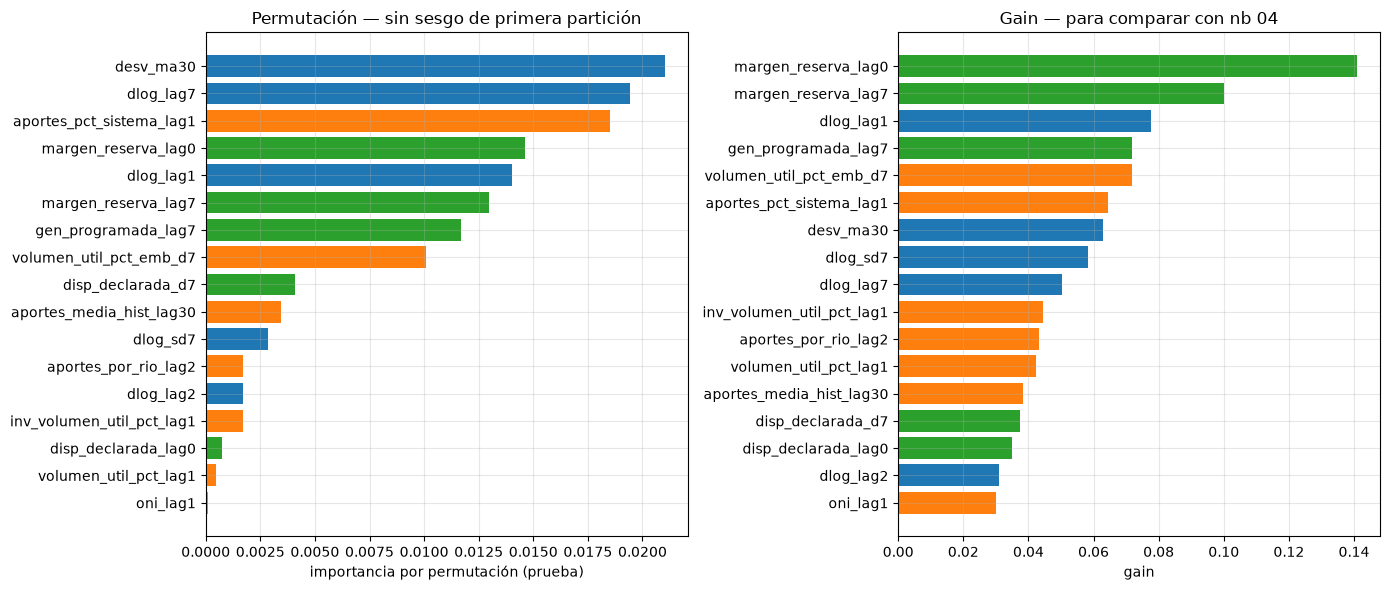

Participación por bloque (permutación, normalizada):
AR_DIFF    0.424
OFERTA     0.317
HIDRO      0.259

Participación por bloque (gain):
OFERTA     0.385
HIDRO      0.335
AR_DIFF    0.280

Feature más dominante por gain: margen_reserva_lag0 (0.141)
Compárala con la feature dominante del notebook 04 (log_precio_lag1)


In [12]:
from sklearn.inspection import permutation_importance

d_dev = pd.concat([X_dev, y_dev], axis=1).dropna()
m_fin = xgb.XGBRegressor(**MEJORES, random_state=CONFIG["seed"],
                         n_jobs=-1, tree_method="hist")
m_fin.fit(d_dev[X.columns].values, d_dev["y"].values)

d_te = pd.concat([X.loc[test_ini:test_fin], y_d.loc[test_ini:test_fin]],
                 axis=1).dropna()
pi = permutation_importance(m_fin, d_te[X.columns].values, d_te["y"].values,
                            n_repeats=15, random_state=CONFIG["seed"], n_jobs=-1)

imp = pd.Series(pi.importances_mean, index=X.columns).sort_values()
gain = pd.Series(m_fin.feature_importances_, index=X.columns)
bloque_de = {f: b for b, lst in FEATURES.items() for f in lst}
col = {b: plt.cm.tab10.colors[i % 10] for i, b in enumerate(FEATURES)}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(imp.index, imp.values, color=[col[bloque_de[f]] for f in imp.index])
axes[0].set_xlabel("importancia por permutación (prueba)")
axes[0].set_title("Permutación — sin sesgo de primera partición")
g = gain.sort_values()
axes[1].barh(g.index, g.values, color=[col[bloque_de[f]] for f in g.index])
axes[1].set_xlabel("gain"); axes[1].set_title("Gain — para comparar con nb 04")
plt.tight_layout(); plt.show()

print("Participación por bloque (permutación, normalizada):")
pos = imp.clip(lower=0)
agg = pos.groupby(pos.index.map(bloque_de)).sum()
print((agg / agg.sum()).sort_values(ascending=False).round(3).to_string())
print("\nParticipación por bloque (gain):")
print(gain.groupby(gain.index.map(bloque_de)).sum().sort_values(ascending=False).round(3).to_string())
print(f"\nFeature más dominante por gain: {gain.idxmax()} ({gain.max():.3f})")
print("Compárala con la feature dominante del notebook 04 (log_precio_lag1)")

## 10. Diagnóstico visual

Mejor: Δ expansiva


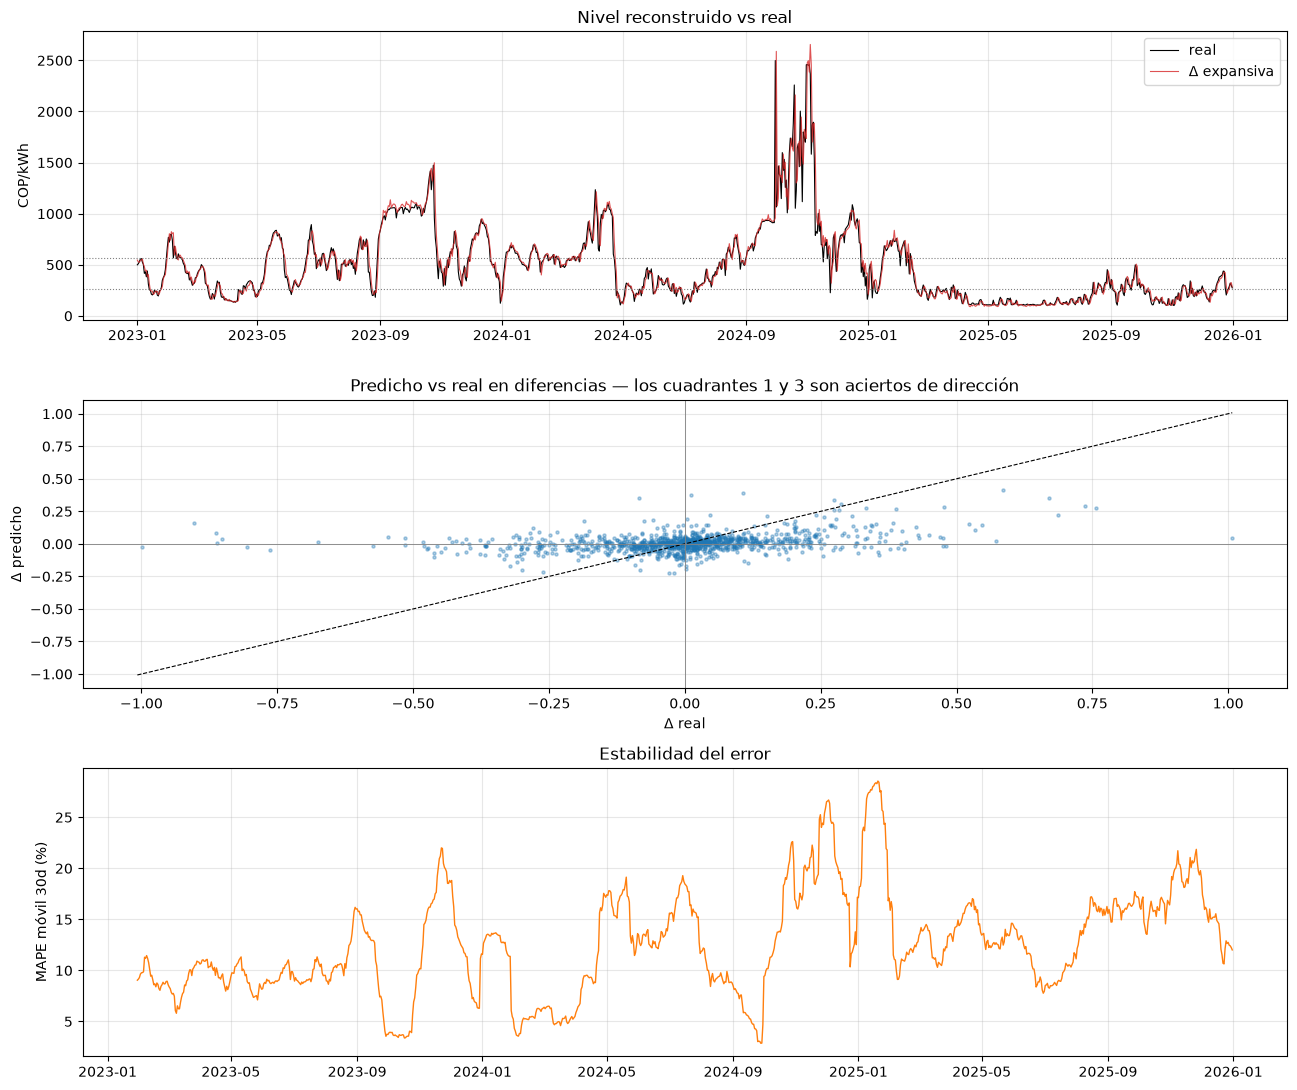

In [13]:
mejor = tabla.loc[MODELOS_DIF, "MAPE_%"].idxmin()
pdd_m, pl_m = modelos[mejor]
print(f"Mejor: {mejor}")

fig, axes = plt.subplots(3, 1, figsize=(13, 11))
ax = axes[0]
ax.plot(test_niv, lw=.8, color="k", label="real")
ax.plot(np.exp(pl_m), lw=.8, color="tab:red", alpha=.8, label=mejor)
ax.axhline(q67, ls=":", c="gray", lw=.8); ax.axhline(q33, ls=":", c="gray", lw=.8)
ax.set_ylabel("COP/kWh"); ax.legend(); ax.set_title("Nivel reconstruido vs real")

ax = axes[1]
dd = pd.concat([y_d.rename("real"), pdd_m.rename("pred")], axis=1).dropna()
ax.scatter(dd["real"], dd["pred"], s=5, alpha=.35)
lim = float(np.abs(dd.values).max())
ax.plot([-lim, lim], [-lim, lim], "k--", lw=.8)
ax.axhline(0, c="gray", lw=.6); ax.axvline(0, c="gray", lw=.6)
ax.set_xlabel("Δ real"); ax.set_ylabel("Δ predicho")
ax.set_title("Predicho vs real en diferencias — los cuadrantes 1 y 3 son aciertos de dirección")

ax = axes[2]
e = (test_niv - np.exp(pl_m)).dropna()
ape = (np.abs(e / test_niv.reindex(e.index)) * 100)
ax.plot(ape.rolling(30).mean(), lw=1, color="tab:orange")
ax.set_ylabel("MAPE móvil 30d (%)"); ax.set_title("Estabilidad del error")
plt.tight_layout(); plt.show()

### Extrapolación: días fuera del rango de entrenamiento

Un árbol no puede predecir un valor mayor que lo que vio al entrenar: cada hoja
devuelve un promedio de observaciones pasadas. En la formulación en **nivel**
eso le pone un techo a la predicción. En la formulación en **diferencia** el
cambio predicho se suma al precio observado de ayer, así que el nivel
reconstruido sí puede superar el máximo histórico.

Aquí se marcan los días de prueba en que el precio real superó el máximo visto
en el reentrenamiento que produjo esa predicción, y se compara el error dentro
y fuera de ese rango.

In [14]:
def techo_entrenamiento(y_nivel, idx, cfg):
    """Maximo del precio visto en el reentrenamiento que produjo cada prediccion
    (ventana expansiva; la deslizante tiene un techo igual o menor)."""
    techo = pd.Series(index=idx, dtype=float)
    fechas = list(idx)
    for i in range(0, len(fechas), cfg["refit_every"]):
        chunk = fechas[i:i + cfg["refit_every"]]
        corte = chunk[0] - pd.Timedelta(days=cfg["horizon"])
        techo.loc[chunk] = y_nivel.loc[:corte].max()
    return techo


techo = techo_entrenamiento(nivel, test_niv.index, CONFIG)
fuera = test_niv > techo
print(f"Días de prueba con precio real SOBRE el máximo visto al entrenar: "
      f"{int(fuera.sum())} de {len(fuera)}")

series_ext = {k: pl for k, (pdd, pl) in modelos.items()}
if tiene_nivel:
    series_ext["NIVEL (nb 04)"] = pl_nivel

if fuera.any():
    detalle = pd.DataFrame({"real": test_niv[fuera],
                            "techo_entrenamiento": techo[fuera]})
    for k, pl in series_ext.items():
        detalle[k] = np.exp(pl.reindex(detalle.index))
    print(detalle.round(1).to_string())

    filas_ext = []
    for k, pl in series_ext.items():
        for grupo, mask in [("dentro de rango", ~fuera), ("fuera de rango", fuera)]:
            sel = test_niv.index[mask.values]
            filas_ext.append({"modelo": k, "grupo": grupo,
                              **metricas(pl.reindex(sel), logp)})
    extrapolacion = pd.DataFrame(filas_ext)
    print("\nMAPE (%) dentro y fuera del rango de entrenamiento")
    print(extrapolacion.pivot(index="modelo", columns="grupo",
                              values="MAPE_%").round(2).to_string())
else:
    extrapolacion = pd.DataFrame()
    print("Ningún día de prueba supera el máximo de entrenamiento.")

Días de prueba con precio real SOBRE el máximo visto al entrenar: 2 de 1096
              real  techo_entrenamiento  Ingenuo (precio ayer)  Δ expansiva  Δ deslizante  NIVEL (nb 04)
fecha                                                                                                   
2024-09-30  2498.8               1942.7                  912.4        957.3         941.3          927.3
2024-10-19  2259.5               1942.7                 1880.4       1811.1        1818.7         1256.7

MAPE (%) dentro y fuera del rango de entrenamiento
grupo                  dentro de rango  fuera de rango
modelo                                                
Ingenuo (precio ayer)            12.81           40.13
NIVEL (nb 04)                    12.50           53.63
Δ deslizante                     12.62           40.92
Δ expansiva                      12.45           40.77


## 11. Guardar

In [15]:
out = Path(CONFIG["out_dir"]); out.mkdir(exist_ok=True)
pd.DataFrame({
    "real_log": logp.reindex(pl_exp.index),
    "real_nivel": nivel.reindex(pl_exp.index),
    "real_dlog": y_d.reindex(pl_exp.index),
    "pred_log_ingenuo": pl_ing,
    "pred_dlog_exp": pd_exp, "pred_log_exp": pl_exp,
    "pred_dlog_des": pd_des, "pred_log_des": pl_des,
    "regimen": regimen,
}).to_csv(out / "predicciones_xgboost_diff.csv")
tabla.to_csv(out / "metricas_xgboost_diff_global.csv")
por_reg.to_csv(out / "metricas_xgboost_diff_regimen.csv", index=False)
tabla_dm.to_csv(out / "dm_xgboost_diff.csv", index=False)
extrapolacion.to_csv(out / "extrapolacion_xgboost_diff.csv", index=False)
if comp is not None:
    comp.to_csv(out / "comparacion_nivel_vs_diferencia.csv")
pd.Series(MEJORES).to_csv(out / "hiperparametros_xgboost_diff.csv")
print(f"Guardado en {out.resolve()}")

print("\nQUÉ REPORTAR EN LA TESIS")
print("  - Si la diferencia gana: justifica d=1 empíricamente, no solo por ACF.")
print("  - Si pierde en MAPE pero gana en acierto direccional: sigue siendo la")
print("    formulación correcta para la capa de sobrecosto, donde la decisión")
print("    de contratar depende del signo, no de la magnitud del error.")
print("  - La comparación entre formulaciones ES un resultado metodológico.")
print("  - Reporta siempre la distancia al pronóstico ingenuo, no solo entre modelos.")

Guardado en C:\Users\andre\OneDrive\cosas de la universidad\Uniandes\VIII\Tesis\salidas_modelos

QUÉ REPORTAR EN LA TESIS
  - Si la diferencia gana: justifica d=1 empíricamente, no solo por ACF.
  - Si pierde en MAPE pero gana en acierto direccional: sigue siendo la
    formulación correcta para la capa de sobrecosto, donde la decisión
    de contratar depende del signo, no de la magnitud del error.
  - La comparación entre formulaciones ES un resultado metodológico.
  - Reporta siempre la distancia al pronóstico ingenuo, no solo entre modelos.


In [16]:
import pandas as pd
cat = pd.read_parquet(r"C:\Users\andre\OneDrive\cosas de la universidad\Uniandes\VIII\Tesis\cache_api\catalogo_metricas.parquet")

filtro = cat["MetricName"].str.contains("Demanda", case=False, na=False) | \
         cat["MetricId"].str.contains("Dema|dema", case=False, na=False)

print(cat.loc[filtro, ["MetricId", "MetricName", "Entity", "MetricDescription"]].to_string())

             MetricId                                                      MetricName                   Entity                                                                                                                                                                                         MetricDescription
0            DemaReal                                        Demanda Real por Sistema                  Sistema                                                                           Demanda de usuarios regulados y no regulados que hacen parte del Sistema Interconectado Nacional (no incluye Alumbrado Público)
1            DemaReal                                         Demanda Real por Agente                   Agente                                                                           Demanda de usuarios regulados y no regulados que hacen parte del Sistema Interconectado Nacional (no incluye Alumbrado Público)
3            DemaCome                                   Deman

In [17]:
from pathlib import Path
cache = Path(r"C:\Users\andre\OneDrive\cosas de la universidad\Uniandes\VIII\Tesis\cache_api")
print("demanda_max_pot" in [p.stem for p in cache.glob("*.parquet")])
print([p.name for p in cache.glob("*.parquet") if "max" in p.name.lower() or "pot" in p.name.lower()])

False
['max_precio_oferta.parquet']
